# InceptionV3 Transfer Learning with Flowers Dataset
This notebook demonstrates how to perform transfer learning using InceptionV3 in Keras with a multi-class Flowers RGB dataset.

In [ ]:
!nvidia-smi

Fri May 30 04:50:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install split-folders -q

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
# Download and unzip dataset
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!mkdir -p ./flowers_dataset
!tar -xvzf flower_photos.tgz -C ./flowers_dataset

--2025-05-30 04:52:17--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.101.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   227MB/s    in 1.0s    

2025-05-30 04:52:18 (227 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flowe

In [ ]:
# Split folders
import splitfolders
splitfolders.ratio("flowers_dataset/flower_photos", output="flowers_split", seed=42, ratio=(.7, .2, .1))

Copying files: 3670 files [00:00, 5361.06 files/s]


In [ ]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=30, zoom_range=0.2,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    'flowers_split/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(
    'flowers_split/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(
    'flowers_split/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 2567 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Found 372 images belonging to 5 classes.


In [ ]:
train_generator.num_classes

5

### Transfer Learning

In [ ]:
# Load InceptionV3 and add custom layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 149, 149,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 147, 147,  │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 147, 147,  │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 73, 73,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 73, 73,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 71, 71,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_192[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,906,085 (91.19 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.5854 - loss: 1.1012 - val_accuracy: 0.8222 - val_loss: 0.5195
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8402 - loss: 0.4805 - val_accuracy: 0.8577 - val_loss: 0.4217
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8887 - loss: 0.3544 - val_accuracy: 0.8536 - val_loss: 0.3864
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9072 - loss: 0.3096 - val_accuracy: 0.8810 - val_loss: 0.3414
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9118 - loss: 0.2805 - val_accuracy: 0.8796 - val_loss: 0.3601
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9156 - loss: 0.2764 - val_accuracy: 0.8769 - val_loss: 0.3277
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9260 - loss: 0.2338 - val_accuracy: 0.8851 - val_loss: 0.3267
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9104 - loss: 0.2634 - val_accuracy: 0.8865 - val_loss

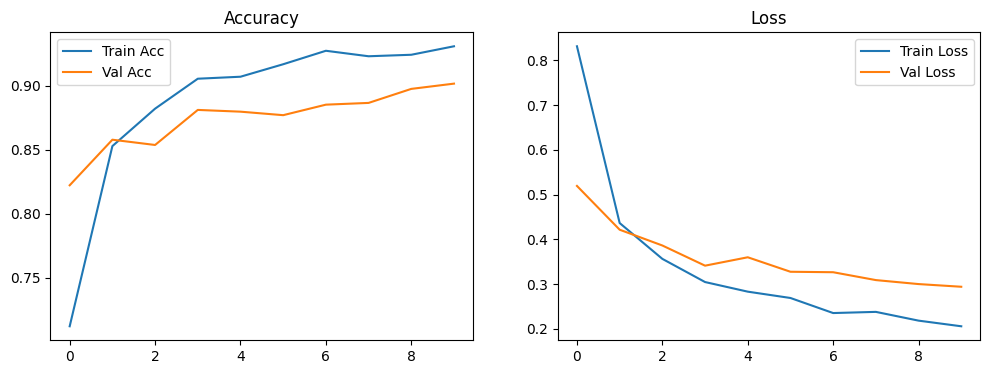

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.9125 - loss: 0.2529
Test Accuracy: 0.8844


In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    class_index = np.argmax(preds)
    class_label = list(train_generator.class_indices.keys())[class_index]
    print(f"Prediction: {class_label} ({preds[0][class_index]*100:.2f}%)")
    # img.show() # This is for PIL Image objects, not needed for matplotlib
    plt.imshow(img) # Use the loaded image for visualization
    plt.axis('off') # Hide axes
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction: roses (99.60%)


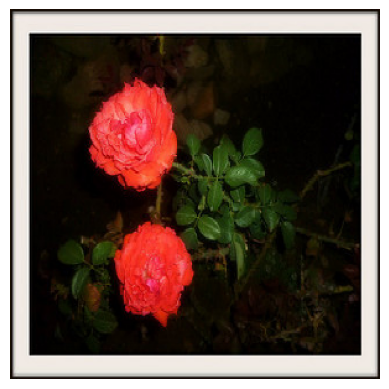

In [ ]:
predict_image("/content/flowers_split/test/roses/15104537437_f6730b38c3_n.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Prediction: sunflowers (98.19%)


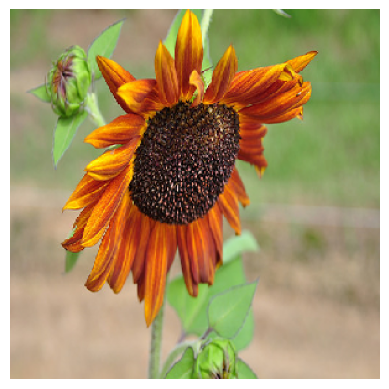

In [ ]:
predict_image("/content/flowers_split/test/sunflowers/13117907313_86c99c6441.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: tulips (99.70%)


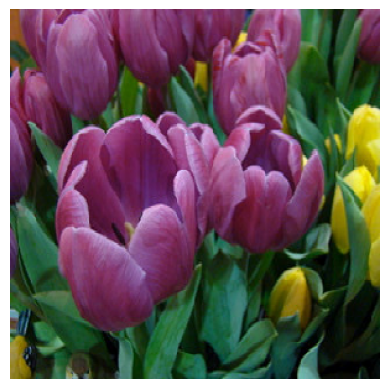

In [ ]:
predict_image("/content/flowers_split/test/tulips/12916441224_2ed63596f8_n.jpg")